<a href="https://colab.research.google.com/github/yalexie1/data-science-fundamentals/blob/main/Stats/YaleXie_MultLinExercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install bambi

Using Python 3.12.13 environment at: /usr
Resolved 46 packages in 1.16s
Prepared 6 packages in 147ms
Installed 6 packages in 18ms
 + arviz-base==0.8.2
 + arviz-plots==0.8.0
 + arviz-stats==0.8.0
 + bambi==0.17.2
 + formulae==0.6.2
 + sparse==0.17.0


In [2]:
from google.colab import files
from google.colab.output import eval_js
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import graphviz as gv
import arviz as az
import pymc as pm
import bambi as bmb

## Exercises

You may use whatever resources you want to complete these exercises, so long as you cite your sources and the use of AI.

I recommend copying and pasting from the examples I did [here](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb); giving you something to copy and paste from was half my intent in writing that lesson.

**Task1**

Get the [penguins data from my github page](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/penguins.csv) into this colab document.

I suggest downloading the csv, and then using the code from [notes document](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb) to upload it into this jupyter notebook.

In [14]:
df = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv")
df.dropna(inplace=True)
df

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


**Task2**

Make a pair plot with the penguins data and describe the scatter plots. Make sure to describe any patterns.

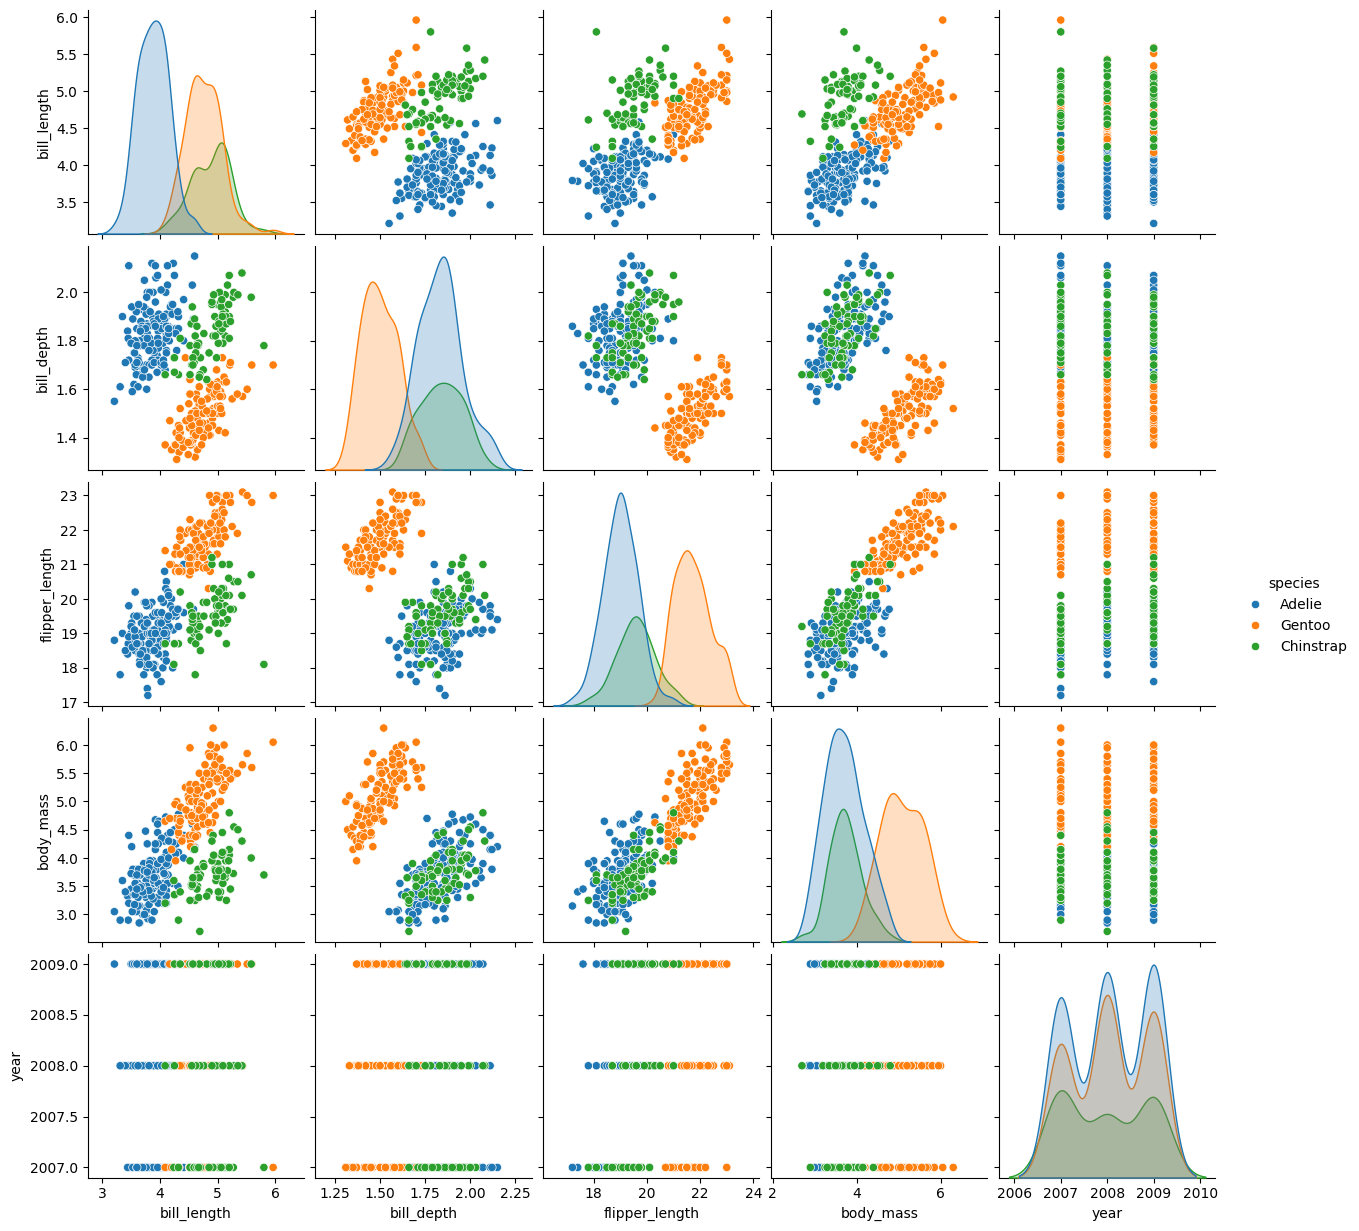

In [17]:
sns.pairplot(df, hue = 'species')

quite a few correlation patterns with distinct groupings of dots indicating different penguin species.

**Task3**

Make a causal diagram corresponding to the penguins data. Remember to include the species variable, even though it likely didn't show up in your pair plot.

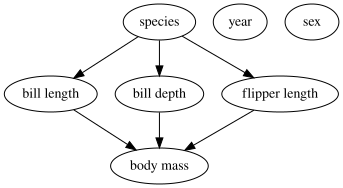

In [51]:
dag = gv.Digraph(name='dag')
dag.node('A', 'bill length')
dag.node('B', 'bill depth')
dag.node('C', 'flipper length')
dag.node('D', 'body mass')
dag.node('E', 'year')
dag.node('F', 'species')
dag.node('G', 'sex')

dag.edges(['FC', 'FB', 'FA', 'AD', 'BD', 'CD'])

dag

**Task4**

Create a Bayesian generalized linear model (GLM) to represent and test your causal diagram.

Then, conduct both types of posterior predictve check, and use them to comment on the model's fit. Note that you may want to make several plots here.

You may use another model type if want--[such as BART](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Unit8/Unit8NotesSF.ipynb)--so long as it is Bayesian, and it represents your causal diagram.

In [ ]:
model_1 = bmb.Model("`body_mass` ~ `bill_length` + `bill_depth` + `flipper_length`", data=df)
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True})

<Axes: xlabel='body_mass'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


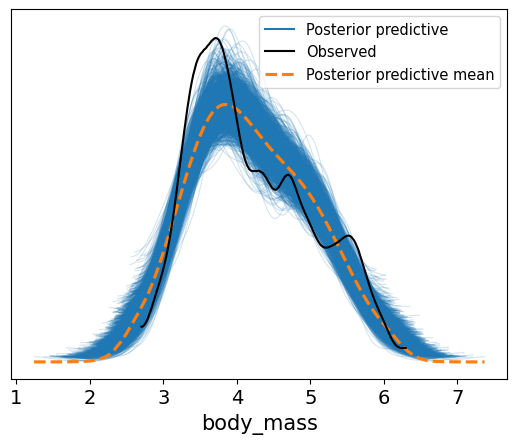

In [35]:
model_1.predict(idata_1, kind="response")
az.plot_ppc(idata_1)

In [ ]:
model_2 = bmb.Model("`body_mass` ~ `bill_length` + `bill_depth` + `flipper_length` + `species`", data=df)
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

<Axes: xlabel='body_mass'>

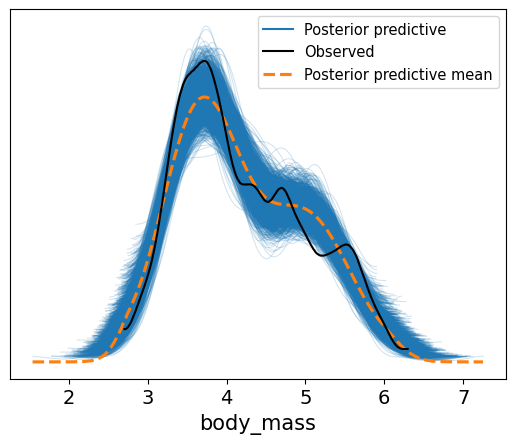

In [36]:
model_2.predict(idata_2, kind="response")
az.plot_ppc(idata_2)

In [ ]:
model_3 = bmb.Model("`body_mass` ~ `bill_length` + `bill_depth` + `flipper_length` + `species` + `bill_length`:`bill_depth`", data=df)
idata_3 = model_3.fit(idata_kwargs={'log_likelihood': True})

<Axes: xlabel='body_mass'>

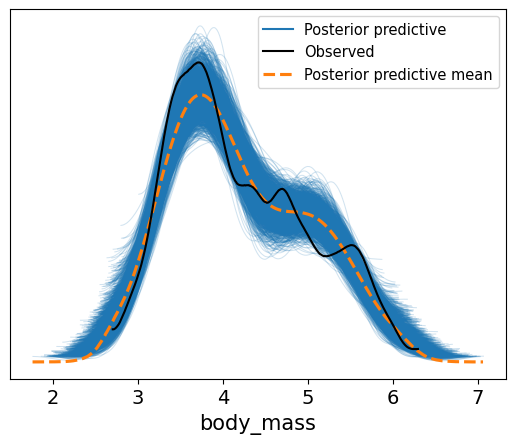

In [42]:
model_3.predict(idata_3, kind="response")
az.plot_ppc(idata_3)

In [ ]:
model_4 = bmb.Model("`body_mass` ~ `bill_length` + `bill_depth` + `flipper_length` + `species` + `sex` + `bill_length`:`bill_depth`", data=df)
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True})

<Axes: xlabel='body_mass'>

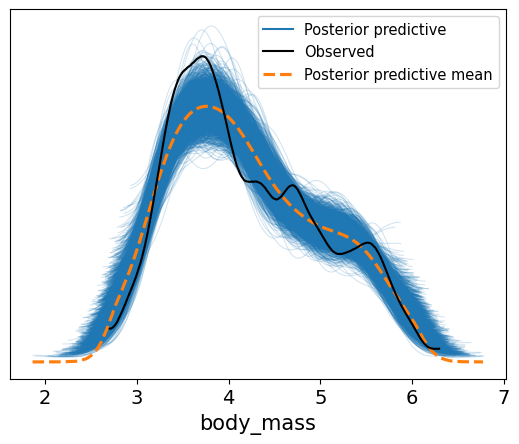

In [48]:
model_4.predict(idata_4, kind="response")
az.plot_ppc(idata_4)

**Task5**

Create as many other models as you need to test your causal hypotheses.

Then, "test" those causal hypotheses using the az.compare and az.plot_compare() functions.

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

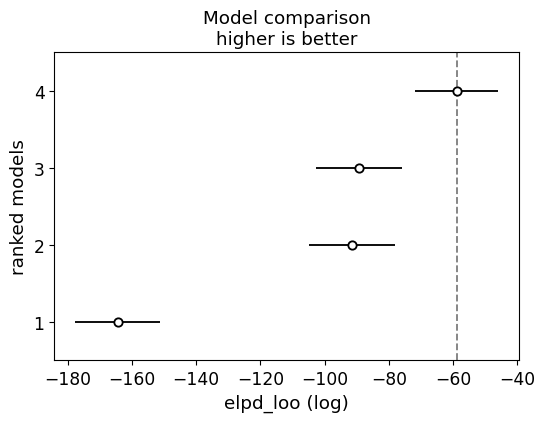

In [50]:
cmp_df = az.compare({"1":idata_1, "2":idata_2, "3":idata_3, "4":idata_4})
az.plot_compare(cmp_df)

**Task6**

Answer the following:

- Which variables were most important?

- Was that surprising? Why?

- Did the model representing your causal diagram perform worse or better than other models?

- What did you learn about the data--and about penguins--from your models?

species was very important as a categorical variable. sex was also very important as a categorical variable which was surprising to me because i thought it wouldn't matter for a penguin. there is a very small interaction between bill length and bill depth.